📊 Quartile Cut Points (Repo Age in Years) with Date Ranges:


,Quartile,Min Age (years),Max Age (years),Start Date,End Date
0,Q1,0.53,4.71,2020-10-28,2024-12-31
1,Q2,4.71,7.07,2018-06-19,2020-10-27
2,Q3,7.07,9.57,2015-12-18,2018-06-18
3,Q4,9.57,17.37,2008-02-29,2015-12-17


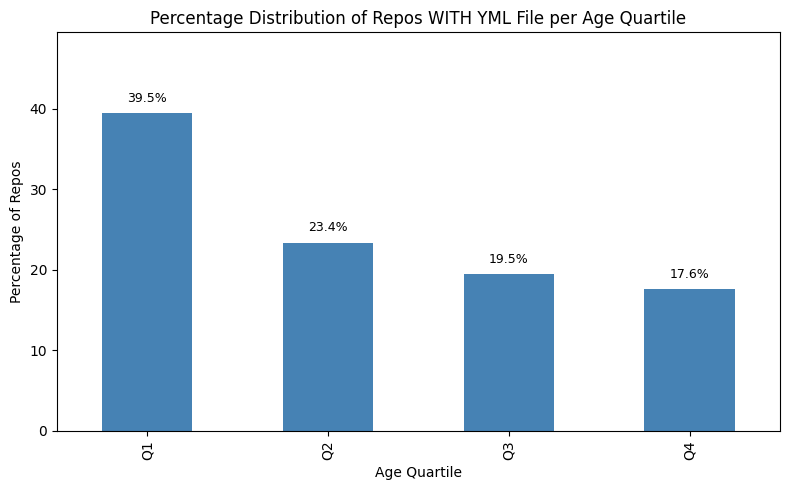

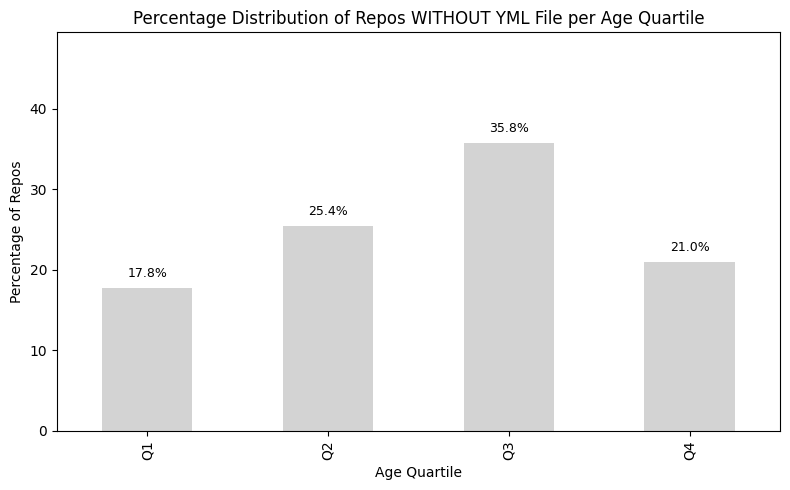

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
%matplotlib inline

# === Step 1: Load file ===
file_path = r"C:\Android Mobile App\Step1_URL_Search\Type_1_Searching_Pipeline_July 14\step4_ci_detection_output.csv"
df = pd.read_csv(file_path)

# === Step 2: Create repo age in years ===
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce').dt.tz_localize(None)
reference_date = pd.to_datetime("2025-07-14")
df['repo_age_years'] = (reference_date - df['created_at']).dt.days / 365.25
df = df.dropna(subset=['repo_age_years'])

# === Step 3: Compute quartiles and assign labels ===
quartile_bounds = df['repo_age_years'].quantile([0, 0.25, 0.5, 0.75, 1.0])
df['age_quartile'] = pd.cut(df['repo_age_years'], 
                            bins=quartile_bounds, 
                            labels=['Q1', 'Q2', 'Q3', 'Q4'], 
                            include_lowest=True)

# === Step 4: Group by quartile and YML detection ===
grouped = df.groupby(['age_quartile', 'yml_detected'], observed=False).size().unstack(fill_value=0)
grouped['total'] = grouped.sum(axis=1)
grouped['yml_rate'] = grouped.get('yes', 0) / grouped['total']
grouped_reset = grouped.reset_index()

# === Step 5: Quartile Summary Table with Age Range and Dates ===
summary = []
labels = ['Q1', 'Q2', 'Q3', 'Q4']
for i in range(4):
    min_age = round(quartile_bounds.iloc[i], 2)
    max_age = round(quartile_bounds.iloc[i+1], 2)
    subset = df[df['age_quartile'] == labels[i]]
    min_date = subset['created_at'].min().date()
    max_date = subset['created_at'].max().date()
    summary.append([labels[i], min_age, max_age, min_date, max_date])

summary_df = pd.DataFrame(summary, columns=['Quartile', 'Min Age (years)', 'Max Age (years)', 'Start Date', 'End Date'])

# === Step 6: Show summary and save updated CSV ===
print("📊 Quartile Cut Points (Repo Age in Years) with Date Ranges:")
display(summary_df)

# Save updated file
df.to_csv(file_path, index=False)

####################################################################
# === Step 1: Filter into Two Groups ===
yml_yes = df[df['yml_detected'] == 'yes']
yml_no = df[df['yml_detected'] == 'no']

# === Step 2: Count by Quartile and convert to percentages ===
yes_counts = yml_yes['age_quartile'].value_counts(normalize=True).sort_index() * 100
no_counts = yml_no['age_quartile'].value_counts(normalize=True).sort_index() * 100
yes_counts = yes_counts.round(1)
no_counts = no_counts.round(1)

# === Plot 1: YML Detected == YES (percent axis) ===
ax1 = yes_counts.plot(
    kind='bar',
    color='steelblue',
    figsize=(8, 5),
    title='Percentage Distribution of Repos WITH YML File per Age Quartile'
)
for i, value in enumerate(yes_counts):
    ax1.text(i, value + 1, f"{value}%", ha='center', va='bottom', fontsize=9)
ax1.set_ylabel("Percentage of Repos")
ax1.set_xlabel("Age Quartile")
ax1.set_ylim(0, max(yes_counts.max(), no_counts.max()) + 10)
plt.tight_layout()
plt.show()

# === Plot 2: YML Detected == NO (percent axis) ===
ax2 = no_counts.plot(
    kind='bar',
    color='lightgray',
    figsize=(8, 5),
    title='Percentage Distribution of Repos WITHOUT YML File per Age Quartile'
)
for i, value in enumerate(no_counts):
    ax2.text(i, value + 1, f"{value}%", ha='center', va='bottom', fontsize=9)
ax2.set_ylabel("Percentage of Repos")
ax2.set_xlabel("Age Quartile")
ax2.set_ylim(0, max(yes_counts.max(), no_counts.max()) + 10)
plt.tight_layout()
plt.show()

###########################################################
# import pandas as pd
# import matplotlib.pyplot as plt

# # === Step 1: Group and normalize for percentage distribution ===
# yml_grouped = df.groupby(['age_quartile', 'yml_detected'], observed=False).size().unstack(fill_value=0).sort_index()

# # Convert counts to percentages for each group
# yml_yes_pct = (yml_grouped['yes'] / yml_grouped['yes'].sum() * 100).round(1)
# yml_no_pct = (yml_grouped['no'] / yml_grouped['no'].sum() * 100).round(1)

# # Combine into one DataFrame for plotting
# combined_pct_df = pd.DataFrame({
#     'YML: Yes': yml_yes_pct,
#     'YML: No': yml_no_pct
# })

# # === Step 2: Plot grouped bar chart ===
# ax = combined_pct_df.plot(
#     kind='bar',
#     figsize=(10, 6),
#     title='Percentage Distribution of Repos with and without YML File per Age Quartile',
#     color=['steelblue', 'lightgray']
# )

# # Add percentage labels on top of bars
# for i in range(len(combined_pct_df)):
#     ax.text(i - 0.15, combined_pct_df.iloc[i, 0] + 1, f"{combined_pct_df.iloc[i, 0]}%", ha='center', va='bottom', fontsize=9)
#     ax.text(i + 0.15, combined_pct_df.iloc[i, 1] + 1, f"{combined_pct_df.iloc[i, 1]}%", ha='center', va='bottom', fontsize=9)

# ax.set_ylabel("Percentage of Repos")
# ax.set_xlabel("Age Quartile")
# ax.set_ylim(0, max(combined_pct_df.max()) + 10)
# ax.legend(title="YML Detected")
# plt.tight_layout()
# plt.show()

